In [52]:
import sys
import json
import numpy as np
from pathlib import Path

import gzip

import matplotlib
# matplotlib.use("Agg")  # headless, no Tk, to avoid issues with parallellisation

import xobjects as xo
import xtrack as xt
import xcoll as xc
helper_dir = Path("/eos/user/l/lpauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions")
sys.path.insert(0, str(helper_dir))  # insert(0, ...) is often better than append

import midpoints_analysis as mpa
import plot_helpers as ph
import intensity_loss as il
import re
from collections import defaultdict

In [36]:
study_path = "/eos/user/l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/studies/ErrorVariants/error_variants"
study_path = Path(study_path).resolve()

In [62]:
error_variants =['dipole_b3', 'dipole_b5', 'dipole_b3b5', 'quadrupole_b4', 'quadrupole_b6', 'quadrupole_b4b6', 'dipole_b3_quadrupole_b4']
chromas = [-1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
planes = ['DPpos', 'DPneg']

In [ ]:
def combine_death_turns(study_path, output_name=None, *, result_path=None, plot_path=None, verbose=True):
    # Combine loss map files and plot
    study_path = Path(study_path).resolve()
    print(study_path)
    if result_path is None:
        result_path = study_path.parents[2] / 'results'
    result_path = Path(result_path).resolve()
    if plot_path is None:
        plot_path = study_path.parents[2] / 'plots'
    plot_path = Path(plot_path).resolve()

    if output_name is None:
        output_name = study_path.stem
    else:
        output_name = output_name + '_'

    files = np.array(list(study_path.glob(f'job_*/death_turns_*.json')))
    if len(files) == 0:
        if verbose:
            print('No death turns files found!')

    

In [47]:
pattern = re.compile(
    r"""
    ^death_turns_
    (?P<error_name>.+)_
    (?P<chroma>-?\d+(?:\.\d+)?)_
    (?P<plane>DPpos|DPneg)
    \.json$
    """,
    re.VERBOSE,
)

In [49]:
fname = "death_turns_dipole_b3_quadrupole_b4_-1.5_DPpos.json"

m = pattern.match(fname)
if not m:
    raise ValueError("Filename does not match pattern")

error_name = m.group("error_name")
chroma = m.group("chroma")
plane = m.group("plane")

print(error_name, chroma, plane)

dipole_b3_quadrupole_b4 -1.5 DPpos


In [51]:
len(m.groups())

3

In [53]:
groups = defaultdict(list)  # (line_type, chroma, plane) -> [Path, Path, ...]

for fp in study_path.glob("job_*/death_turns_*.json"):
    m = pattern.match(fp.name)
    if not m:
        continue
    key = m.groups()  # (line_type, chroma, plane)
    groups[key].append(fp)

In [55]:
groups[('dipole_b3',
              '-0.1',
              'DPneg')]

[PosixPath('/eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/studies/ErrorVariants/error_variants/job_0/death_turns_dipole_b3_-0.1_DPneg.json'),
 PosixPath('/eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/studies/ErrorVariants/error_variants/job_1/death_turns_dipole_b3_-0.1_DPneg.json'),
 PosixPath('/eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/studies/ErrorVariants/error_variants/job_10/death_turns_dipole_b3_-0.1_DPneg.json'),
 PosixPath('/eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/studies/ErrorVariants/error_variants/job_100/death_turns_dipole_b3_-0.1_DPneg.json'),
 PosixPath('/eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/studies/ErrorVariants/error_variants/job_101/death_turns_dipole_b3_-0.1_DPneg.json'),
 PosixPath('/eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/studies/ErrorVariants/error_variants/job_102/death_turns_dipole_b3_-0.1_DPneg.json'),
 PosixPath('/eos/home

In [56]:
def combine_death_turns(study_path, output_name=None, *, result_path=None, plot_path=None, verbose=True):
    # Combine loss map files and plot
    study_path = Path(study_path).resolve()
    print(study_path)
    if result_path is None:
        result_path = study_path.parents[2] / 'results'
    result_path = Path(result_path).resolve()
    if plot_path is None:
        plot_path = study_path.parents[2] / 'plots'
    plot_path = Path(plot_path).resolve()
    if output_name is None:
        output_name = ''
    else:
        output_name = output_name + '_'

    files = np.array(list(study_path.glob(f'job_*/death_turns_*.json')))
    if len(files) == 0:
        if verbose:
            print('No death turns files found!')
        return
    if verbose:
        print(f'Found {len(files)} death turns files')
    
    
    pattern = re.compile(
        r"""
        ^death_turns_
        (?P<line_type>.+)_
        (?P<chroma>-?\d+(?:\.\d+)?)_
        (?P<plane>DPpos|DPneg)
        \.json$
        """,
        re.VERBOSE,
    )

    groups = defaultdict(list)  # (line_type, chroma, plane) -> [Path, Path, ...]

    for fp in study_path.glob("job_*/death_turns_*.json"):
        m = pattern.match(fp.name)
        if not m:
            continue
        key = m.groups()  # (line_type, chroma, plane)
        groups[key].append(fp) 

    for (lt, chroma, plane), file_list in groups.items():
        if verbose:
            print(f'Combining death turns for {lt}, chroma={chroma}, plane={plane}, from {len(file_list)} files')
        combined_death_turns = {'sweep_per_turn': 0, 'at_turn': []}
        for file in file_list:
            with open(file, 'r') as f:
                data = json.load(f)
            if combined_death_turns['sweep_per_turn'] == 0:
                combined_death_turns['sweep_per_turn'] = data['sweep_per_turn']
            combined_death_turns['at_turn'].extend(data['at_turn'])
    

        output_file = result_path / f'{output_name}death_turns_{lt}_{chroma}_{plane}.json.gz'
        if verbose:
            print(f'Writing combined death turns to {output_file}')

        with gzip.open(output_file, 'wt', encoding='utf-8') as f:
            json.dump(combined_death_turns, f)

In [57]:
combine_death_turns(study_path, result_path=study_path.parents[2] / 'results' / 'JsonFiles')

/eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/studies/ErrorVariants/error_variants
Found 216893 death turns files
Combining death turns for dipole_b3, chroma=-0.1, plane=DPneg, from 500 files
Writing combined death turns to /eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles/death_turns_dipole_b3_-0.1_DPneg.json.gz
Combining death turns for dipole_b3, chroma=-0.1, plane=DPpos, from 500 files
Writing combined death turns to /eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles/death_turns_dipole_b3_-0.1_DPpos.json.gz
Combining death turns for dipole_b3, chroma=-0.2, plane=DPneg, from 500 files
Writing combined death turns to /eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles/death_turns_dipole_b3_-0.2_DPneg.json.gz
Combining death turns for dipole_b3, chroma=-0.2, plane=DPpos, from 500 files
Writing combined death turns to /eos/home-l/lpauwels/Simulations/MomentumAcceptance

In [58]:
def load_data(line_types, chromas, planes, result_path=None, verbose=True):
    if result_path is None:
        result_path = study_path.parents[2] / 'results'
    result_path = Path(result_path).resolve()

    data = {}
    for lt in line_types:
        data[lt] = {}
        for chroma in chromas:
            data[lt][chroma] = {}
            for plane in planes:
                data[lt][chroma][plane] = {}
                file_path = result_path / f'death_turns_{lt}_{chroma}_{plane}.json.gz'
                if not file_path.exists():
                    if verbose:
                        print(f'File {file_path} does not exist, skipping')
                    continue
                if verbose:
                    print(f'Loading data from {file_path}')
                with gzip.open(file_path, 'rt', encoding='utf-8') as f:
                    death_turns_data = json.load(f)
                turns, counts = np.unique(death_turns_data['at_turn'], return_counts=True)
                data[lt][chroma][plane] = {'turns' : turns, 'counts' : counts}
    return data

In [59]:
def df_to_delta(df):
    slip_factor = 0.0017935055033301713
    f = 200_000_000
    return 1/slip_factor * df/f

In [66]:
def get_normalised_intensity_loss(data, line_types, chromas, planes, total_particles, sweep_per_turn=1.0):
    normalised_intensity_loss = {}
    for lt in line_types:
        normalised_intensity_loss[lt] = {}
        for chroma in chromas:
            normalised_intensity_loss[lt][chroma] = {}
            for plane in planes:
                turns = data[lt][chroma][plane]['turns']
                counts = data[lt][chroma][plane]['counts']

                turns = np.concatenate(([0], turns))
                counts = np.concatenate(([0], counts))

                deltas = df_to_delta(turns * sweep_per_turn)
                if plane == 'DPneg':
                    deltas = -deltas
                
                normalised_intensity_loss[lt][chroma][plane] = {'deltas': deltas, 'values': 1 - np.cumsum(counts) / total_particles}
    return normalised_intensity_loss

# Plots

In [63]:
data = load_data(error_variants, chromas, planes, result_path=Path('/eos/user/l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles'))

Loading data from /eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles/death_turns_dipole_b3_-1.5_DPpos.json.gz
Loading data from /eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles/death_turns_dipole_b3_-1.5_DPneg.json.gz
Loading data from /eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles/death_turns_dipole_b3_-1.4_DPpos.json.gz
Loading data from /eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles/death_turns_dipole_b3_-1.4_DPneg.json.gz
Loading data from /eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles/death_turns_dipole_b3_-1.3_DPpos.json.gz
Loading data from /eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles/death_turns_dipole_b3_-1.3_DPneg.json.gz
Loading data from /eos/home-l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/results/JsonFiles/death_turns_dipole_b3_-1.2_DPpos.json.gz

In [67]:
normalised_intensity = get_normalised_intensity_loss(data, error_variants, chromas, planes, total_particles=1_000_000, sweep_per_turn=1.0)

In [75]:
path_MD_data = Path('/eos/user/l/lpauwels/sps_simulations/MD_data/20250616/')
path_study_results = Path("/eos/user/l/lpauwels/Simulations/MomentumAcceptance/IntensityScan2/study_results")
name_files = [p.name for p in path_study_results.iterdir()]

sweep_per_turn = 1.0
data2 = {'linear' : {}, 'errors': {}}
for name_file in name_files:
    with gzip.open(path_study_results / name_file, "rt") as f:
        study_results = json.load(f)

    line_type = name_file.split("_")[1]
    chroma = float(name_file.split("_")[2].split(".json")[0])
    print(line_type, chroma)
    if chroma not in data2[line_type]:
        data2[line_type][chroma] = {}
    
    for plane in list(study_results.keys()):
        assert abs(study_results[plane]['sweep_per_turn']) == sweep_per_turn
        turns, counts = np.unique(study_results[plane]['at_turn'], return_counts=True)
        data2[line_type][chroma][plane] = {'turns' : turns, 'counts' : counts}

normalised_intensity2 = {}
num_particles = 2000 * 500
for line_type in ['linear', 'errors']:
    normalised_intensity2[line_type] = {}
    for chroma in sorted(data2[line_type].keys()):
        normalised_intensity2[line_type][chroma] = {}
        for plane in ['DPpos', 'DPneg']:
            turns = data2[line_type][chroma][plane]['turns']
            counts = data2[line_type][chroma][plane]['counts']

            turns = np.concatenate(([0], turns))
            counts = np.concatenate(([0], counts))

            deltas = mpa.df_to_delta(turns * sweep_per_turn)
            if plane == 'DPneg':
                deltas = -deltas
            
            normalised_intensity2[line_type][chroma][plane] = {'deltas': deltas, 'values': 1 - np.cumsum(counts) / num_particles}

normalised_intensity['linear'] = normalised_intensity2['linear']
normalised_intensity['errors_all'] = normalised_intensity2['errors']

errors -0.1
errors -0.2
errors -0.3
errors -0.4
errors -0.5
errors -0.6
errors -0.7
errors -0.8
errors -0.9
errors -1.0
errors -1.1
errors -1.2
errors -1.3
errors -1.4
errors -1.5
errors 0.0
errors 0.1
errors 0.2
errors 0.3
errors 0.4
errors 0.5
errors 0.6
errors 0.7
errors 0.8
errors 0.9
errors 1.0
errors 1.1
errors 1.2
errors 1.3
errors 1.4
errors 1.5
linear -0.1
linear -0.2
linear -0.3
linear -0.4
linear -0.5
linear -0.6
linear -0.7
linear -0.8
linear -0.9
linear -1.0
linear -1.1
linear -1.2
linear -1.3
linear -1.4
linear -1.5
linear 0.0
linear 0.1
linear 0.2
linear 0.3
linear 0.4
linear 0.5
linear 0.6
linear 0.7
linear 0.8
linear 0.9
linear 1.0
linear 1.1
linear 1.2
linear 1.3
linear 1.4
linear 1.5


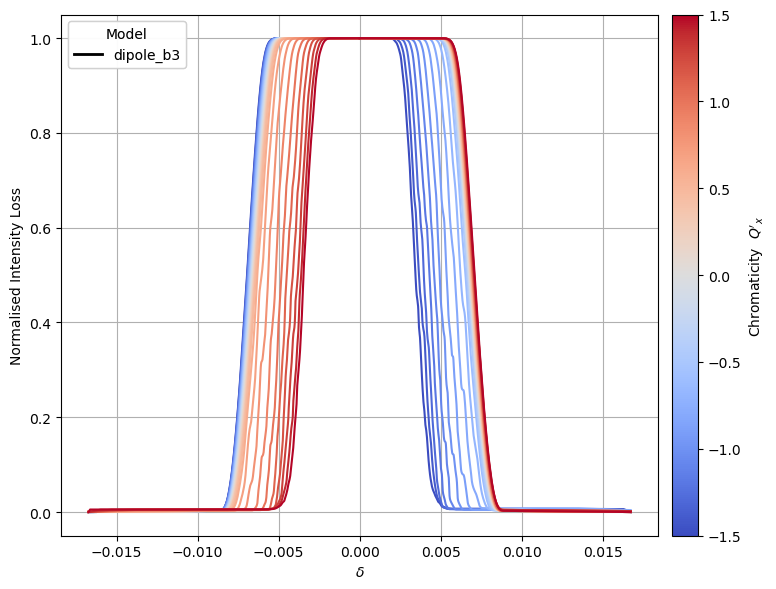

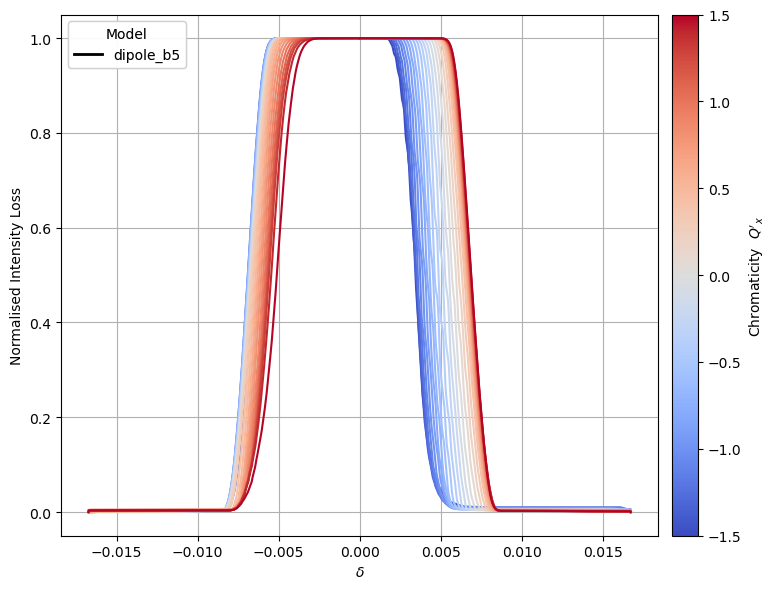

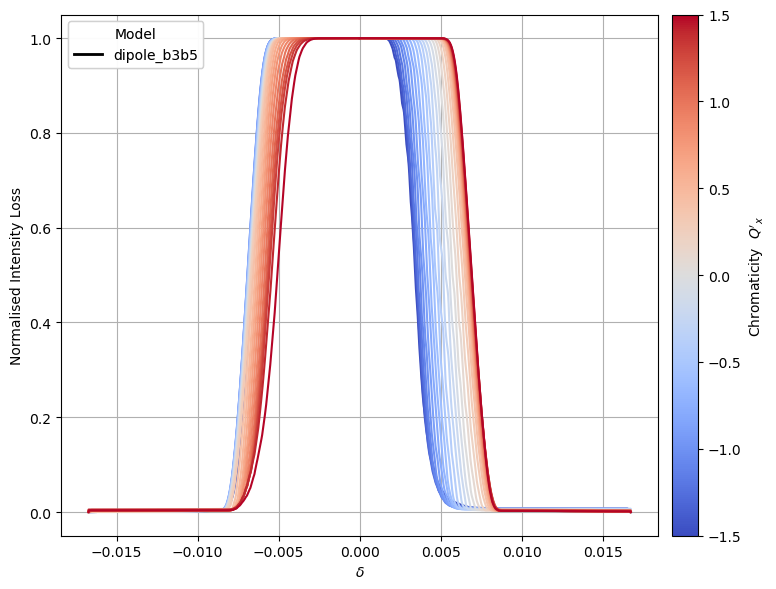

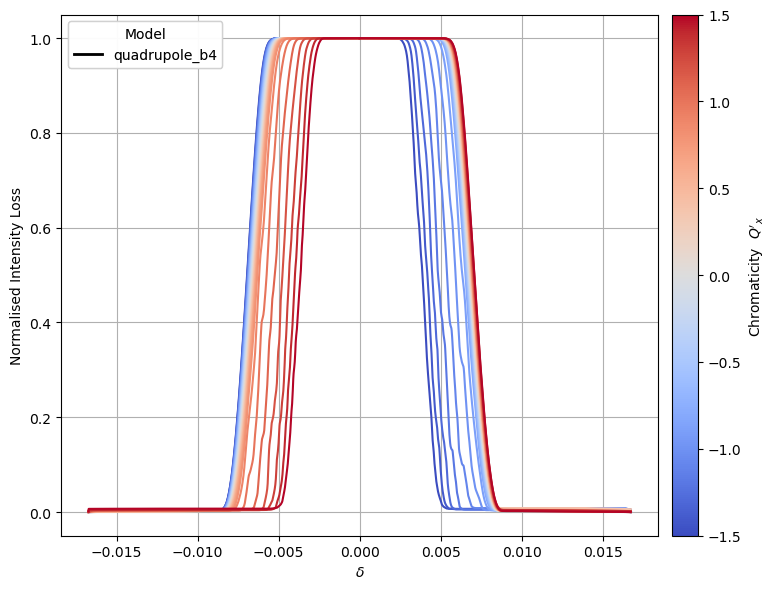

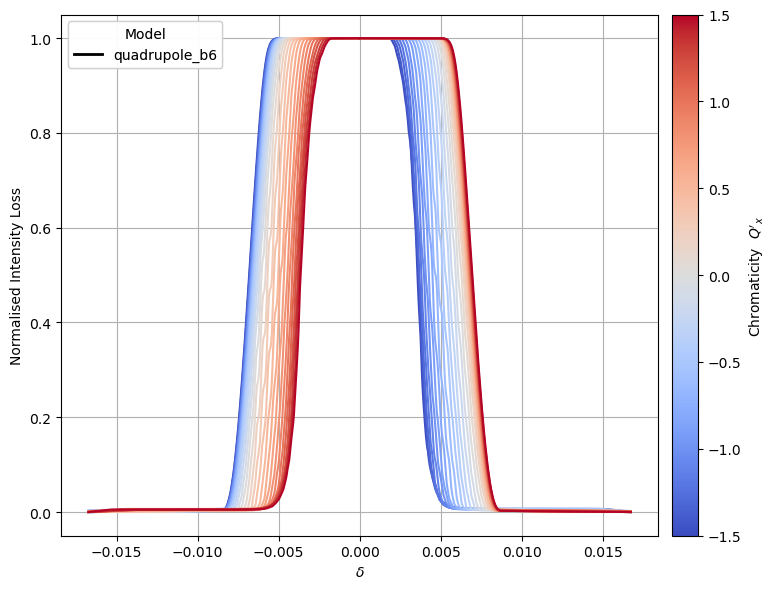

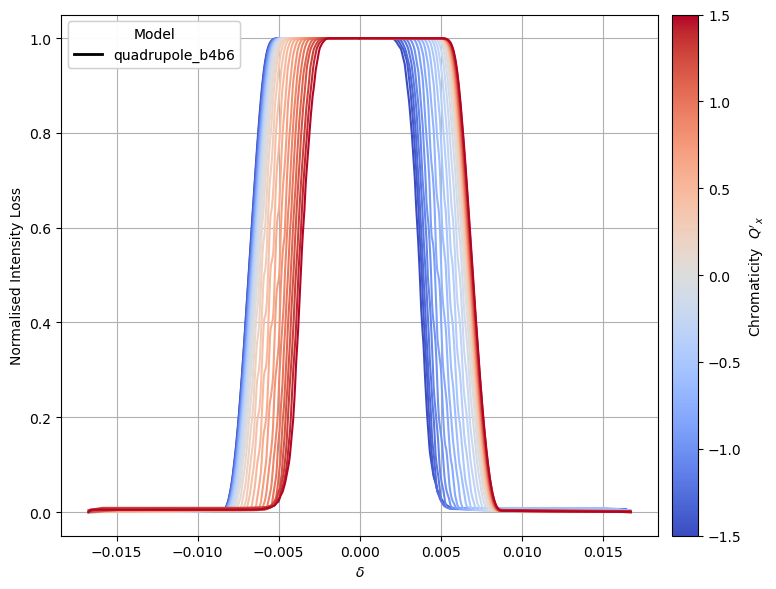

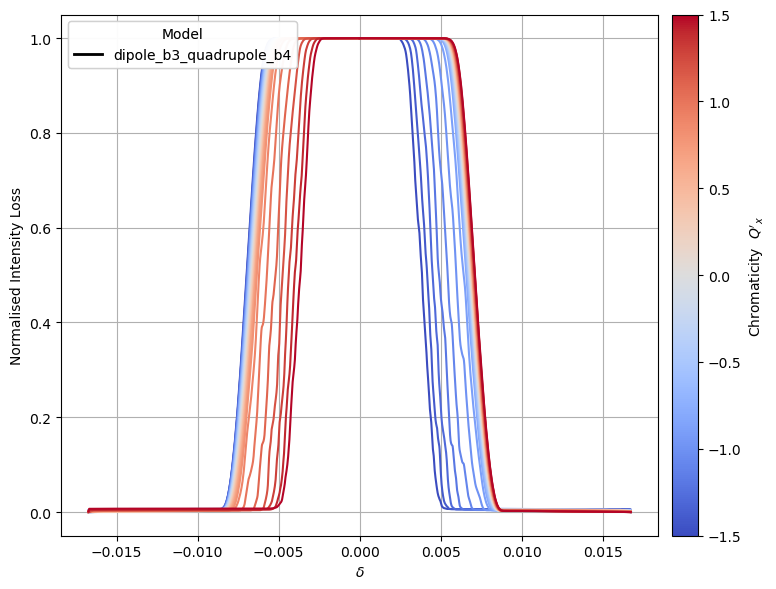

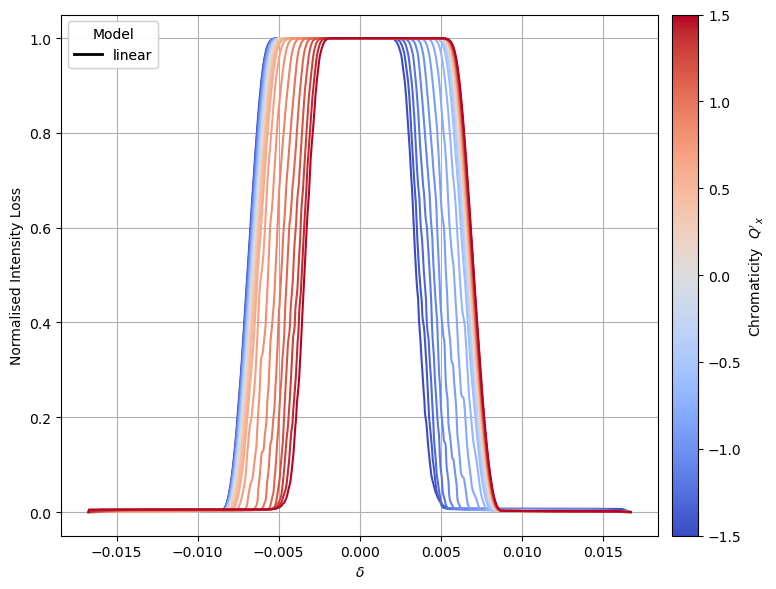

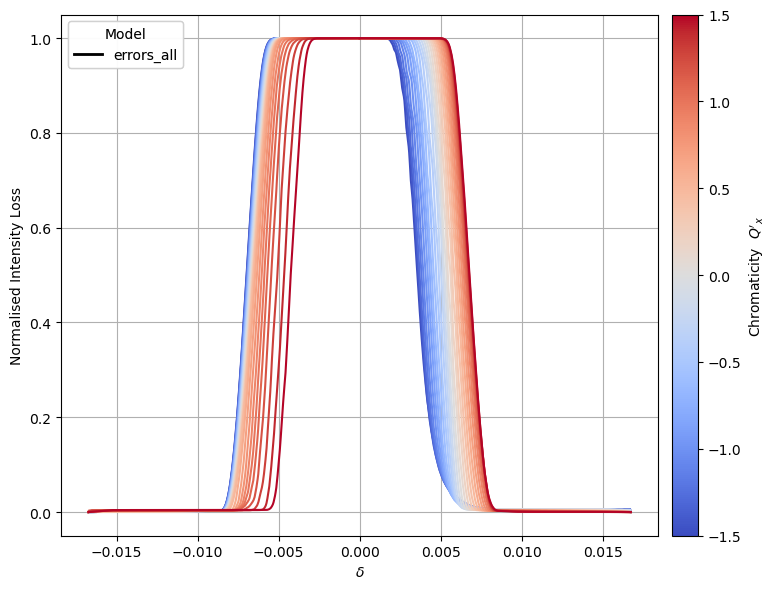

In [76]:
error_variants.extend(['linear', 'errors_all'])
for lt in error_variants:
    il.plot_intensity_drop(normalised_intensity, line_types=[lt], savefig=f'IntensityLoss/{lt}.png')

In [77]:
midpoints = mpa.get_midpoints(normalised_intensity)

In [79]:
with open(path_MD_data/'midpoints_MD.json') as f:
    midpoints_md = json.load(f)

midpoints_md = mpa.restructure_md_midpoints(midpoints_md)

In [80]:
savepath = Path('/eos/user/l/lpauwels/Simulations/MomentumAcceptance/ErrorVariants/Figures/Middpoints')

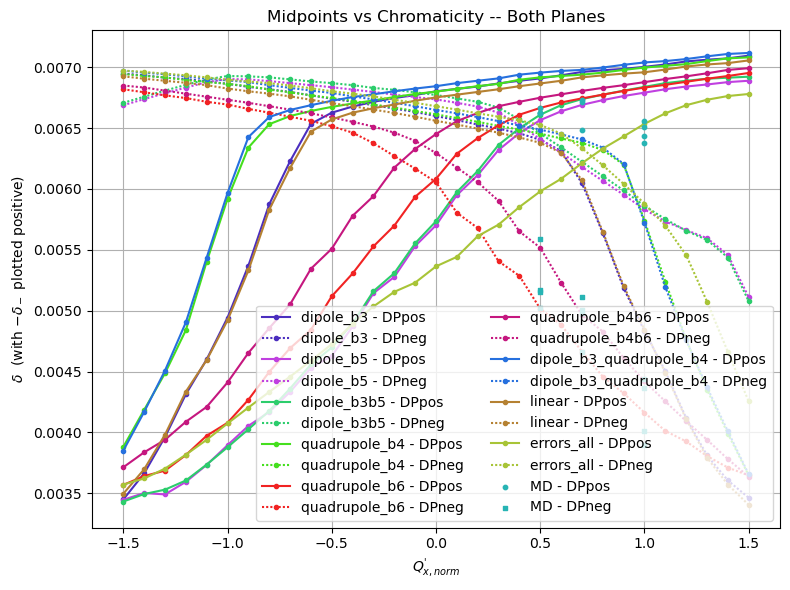

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Midpoints vs Chromaticity -- Both Planes'}, xlabel="$Q_{x, norm}^'$", ylabel='$\\delta$  (with $-\\delta_-$ plotted positive)'>)

In [87]:
mpa.plot_midpoints(midpoints, midpoints_md, planes = ['DPpos', 'DPneg'], savefig='Midpoints/midpoints_all.png')

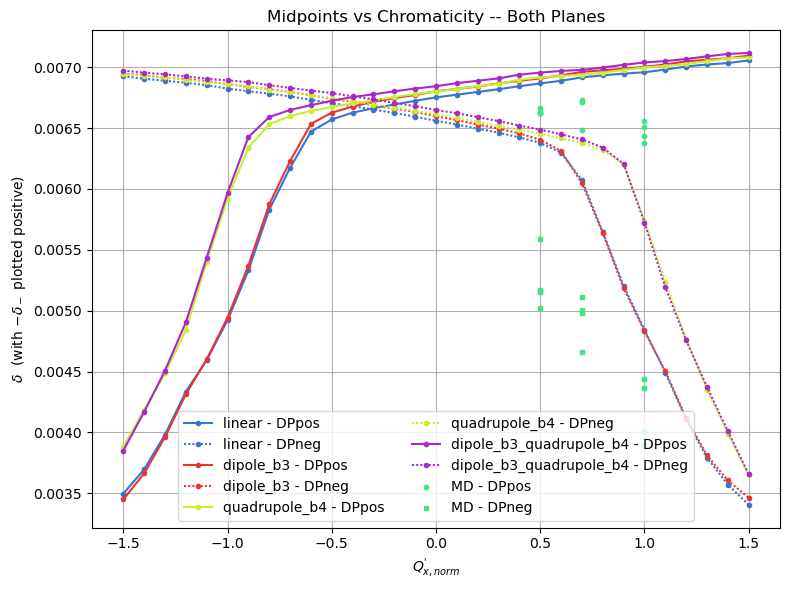

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Midpoints vs Chromaticity -- Both Planes'}, xlabel="$Q_{x, norm}^'$", ylabel='$\\delta$  (with $-\\delta_-$ plotted positive)'>)

In [91]:
mpa.plot_midpoints(midpoints, midpoints_md, line_types=['linear', 'dipole_b3', 'quadrupole_b4', 'dipole_b3_quadrupole_b4'],planes = ['DPpos', 'DPneg'])

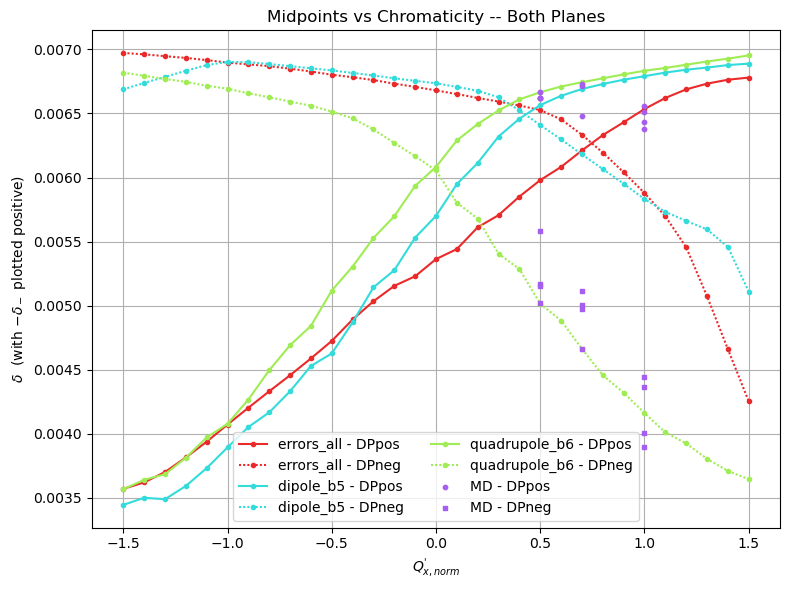

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Midpoints vs Chromaticity -- Both Planes'}, xlabel="$Q_{x, norm}^'$", ylabel='$\\delta$  (with $-\\delta_-$ plotted positive)'>)

In [90]:
mpa.plot_midpoints(midpoints, midpoints_md, line_types=['errors_all', 'dipole_b5', 'quadrupole_b6'],planes = ['DPpos', 'DPneg'])